In [1218]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
from scipy.stats import norm
from scipy.stats import sem

In [3]:
rng = np.random.default_rng()

\begin{equation}
\partial_{\tilde{t}}{\mathbf{\tilde{r}}} = \mathbf{\hat{n}} + \mathbf{\tilde{F}}
\end{equation}
\begin{equation}
\partial_{\tilde{t}}{\theta} = 1 + \tilde{\omega} + \mathbf{\tilde{F}} \cdot \mathbf{\hat{n}} + \sqrt{2 \tilde{D}_r} \, \tilde{\xi}
\end{equation}
\begin{equation}
\langle \tilde{\xi}(\tilde{t}) \, \tilde{\xi}(\tilde{s}) \rangle = \delta(\tilde{t} - \tilde{s})
\end{equation}

There are effectively 4 constants: $\tilde{k}$, $\tilde{\omega}$, $\tilde{D}_r$, $\tilde{L}$. These are, respectively, the (reduced) stiffness of the wall, internal frequency, rotational diffusion constant and channel width.

In [4]:
def pot(k, L, x, y):

    if x < 0:
        V = 0.5*k*x*x
    elif 0 <= x <= L:
        V = 0
    elif x > L:
        V = 0.5*k*(x-L)*(x-L)

    return V

In [5]:
def force_left(k, L, x, y):

    if x < 0:
        force = -k*x
    else:
        force = 0

    return force

In [6]:
def force_right(k, L, x, y):

    if x > L:
        force = -k*(x - L)
    else:
        force = 0

    return force

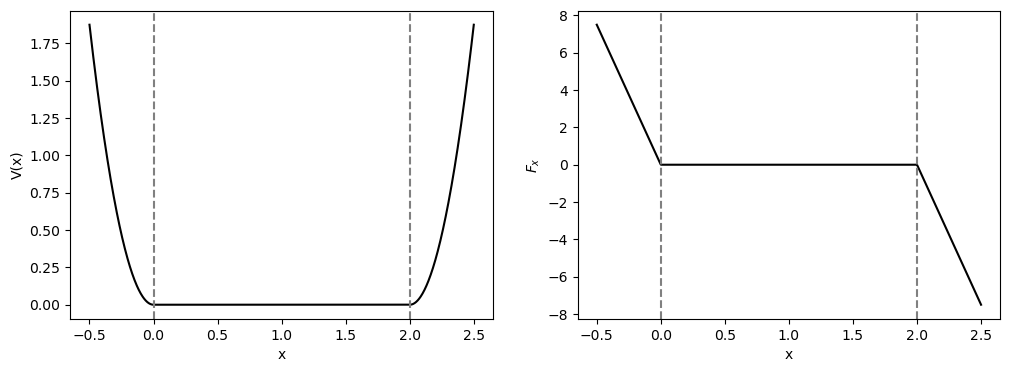

In [7]:
x = np.linspace(-0.5, 2.5, 1000)
y1 = np.zeros(len(x))
y2 = np.zeros(len(x))
for i in range(len(x)):
    y1[i] = pot(15, 2.0, x[i], 0)
for i in range(len(x)):
    y2[i] = force_left(15, 2.0, x[i], 0) + force_right(15, 2.0, x[i], 0)
    
fig = plt.figure(figsize = (12, 4))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x, y1, color = 'black')
ax1.axvline(0, color = 'grey', linestyle = '--')
ax1.axvline(2, color = 'grey', linestyle = '--')
ax1.set_xlabel('x')
ax1.set_ylabel('V(x)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, y2, color = 'black')
ax2.axvline(0, color = 'grey', linestyle = '--')
ax2.axvline(2, color = 'grey', linestyle = '--')
ax2.set_xlabel('x')
ax2.set_ylabel(r"$F_x$")

#fig.savefig('pot_and_force')

In [8]:
def euler_maruyama_step(k, w, D_r, L, delta_t, x_t, y_t, theta_t):
    
    x_tpdt = x_t + np.cos(theta_t)*delta_t + (force_left(k, L, x_t, y_t) + force_right(k, L, x_t, y_t))*delta_t
    y_tpdt = y_t + np.sin(theta_t)*delta_t

    d_beta = rng.normal(0, np.sqrt(delta_t))
    theta_tpdt = theta_t + (1 + w)*delta_t + (force_left(k, L, x_t, y_t) + 
                                      force_right(k, L, x_t, y_t))*np.cos(theta_t)*delta_t + np.sqrt(2*D_r)*d_beta

    return x_tpdt, y_tpdt, theta_tpdt

In [9]:
def trig_step(k, w, D_r, L, delta_t, x_t, y_t, theta_t):

    x_tpdt = (x_t + np.cos(theta_t)*delta_t + (force_left(k, L, x_t, y_t) + force_right(k, L, x_t, y_t))*delta_t +
                         0.5*(force_left(k, L, x_t, y_t) + force_right(k, L, x_t, y_t))*(der_left(k, L, x_t, y_t) 
                                                                            + der_right(k, L, x_t, y_t))*delta_t*delta_t)
    y_tpdt = y_t + np.sin(theta_t)*delta_t

    d_beta = rng.normal(0, np.sqrt(delta_t))
    d_zeta = 0.5*d_beta*delta_t
    theta_tpdt = (theta_t + (1 + w)*delta_t + (force_left(k, L, x_t, y_t) + 
                        force_right(k, L, x_t, y_t))*np.cos(theta_t)*delta_t + np.sqrt(2*D_r)*d_beta +
                        np.sqrt(2*D_r)*(der_left(k, L, x_t, y_t) + der_right(k, L, x_t, y_t))*np.cos(theta_t)*d_zeta +
                        0.5*((1 + w + (force_left(k, L, x_t, y_t) + force_right(k, L, x_t, y_t))*np.cos(theta_t))*(der_left(k, L, x_t, y_t) 
                                                                            + der_right(k, L, x_t, y_t))*np.cos(theta_t))*delta_t*delta_t)

    return x_tpdt, y_tpdt, theta_tpdt

In [11]:
def particle_trajectory(k, w, D_r, L, delta_t, N, x0, y0, theta0):
    
    x = x0
    y = y0
    theta = theta0
    #x_array = np.array([x])
    x_array = np.zeros(N)
    #y_array = np.array([y])
    y_array = np.zeros(N)
    #theta_array = np.array([theta])
    theta_array = np.zeros(N)
    x_array[0] = x0
    y_array[0] = y0
    theta_array[0] = theta0
    tot_steps = 1

    while tot_steps < N:
        x, y, theta = euler_maruyama_step(k, w, D_r, L, delta_t, x, y, theta)
    
        x_array[tot_steps] = x
        y_array[tot_steps] = y
        theta_array[tot_steps] = theta
        tot_steps += 1 
        if y > L/2:
            y = -L/2 + (y - L/2)
        if y < -L/2:
            y = L/2 + (y + L/2)

    return x_array, y_array, theta_array

In [456]:
x, y, t = particle_trajectory(18, -0.60, 0.3, 2.0, 0.01, 30*50000, 1.0, 0.0, 0.8)

In [457]:
diffs = np.append(np.diff(y), 0)
discont_indices = np.abs(diffs) > 1
y[discont_indices] = np.nan

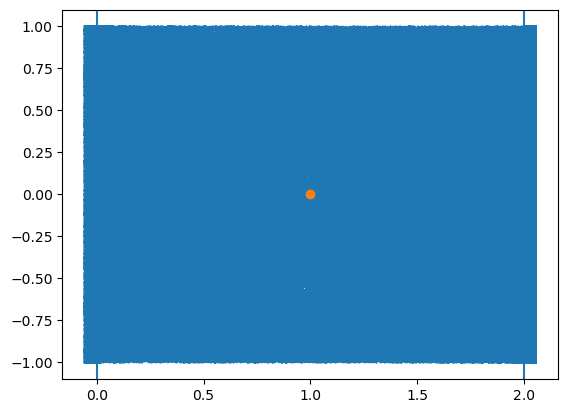

In [458]:
plt.plot(x, y)
plt.plot(1.0, 0, 'o')
plt.axvline(0)
plt.axvline(2.0)

In [1996]:
x_example = x
y_example = y

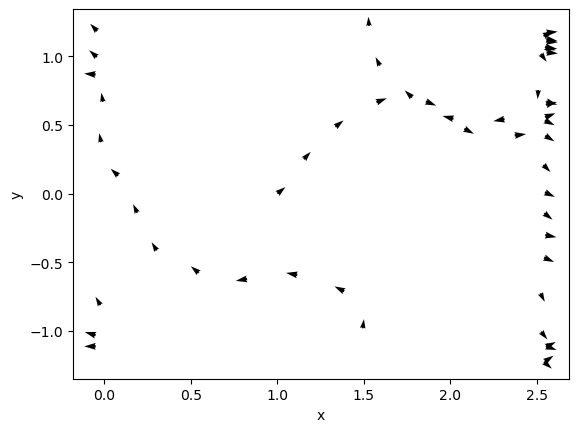

In [2003]:
for i in range(54):
    xi = x_example[30*i]
    yi = y_example[30*i]
    theta = t[30*i]

    dx = np.cos(theta)
    dy = np.sin(theta)

    #plt.axvline(0, color = 'white', linestyle = '--')
    #plt.axvline(2.5, color = 'white', linestyle = '--')
    #plt.plot(xi, yi, '.', color='black')
    plt.quiver(xi, yi, dx, dy, angles='xy', scale_units='xy', scale=15, color='black')
    plt.xlabel('x')
    plt.ylabel('y')

#plt.savefig('typical_trajectory')

In [595]:
Trials = 100
MSD = 0
for i in range(Trials):
    x, y, t = particle_trajectory(15, -0.3, 0.1, 0.2, 0.01, 45000, 0.1, 0.0, 0)
    MSD += (y - y[0])**2

MSD = MSD/Trials

KeyboardInterrupt: 

In [390]:
time_arr = np.arange(0, 45000*0.01+0.001, 0.01)
print(time_arr)

[0.0000e+00 1.0000e-02 2.0000e-02 ... 4.4998e+02 4.4999e+02 4.5000e+02]


In [392]:
m, b = np.polyfit(time_arr, MSD, 1)

In [394]:
print(m)
print(b)

12.503523608349727
-96.43011079798428


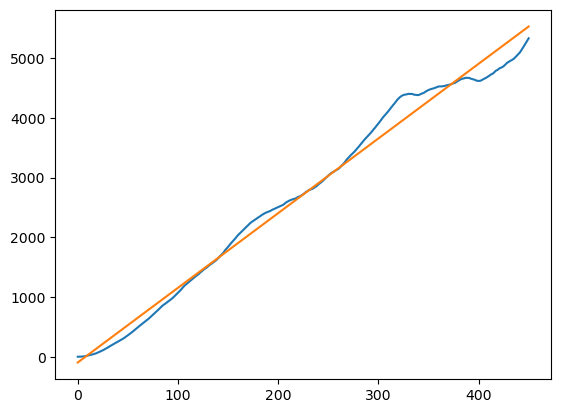

In [395]:
plt.plot(time_arr, MSD)
plt.plot(time_arr, m*time_arr + b)

In [396]:
D_arr = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3])
D_L = np.zeros(6)
for i in range(6):
    MSD = 0
    for j in range(Trials):
        x, y, t = particle_trajectory(15, -0.3, D_arr[i], 0.2, 0.01, 45000, 0.1, 0.0, 0)
        MSD += (y - y[0])**2

    MSD = MSD/Trials
    m, b = np.polyfit(time_arr, MSD, 1)
    D_L[i] = m/2

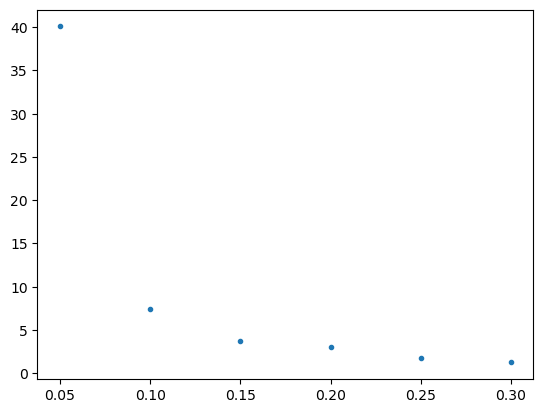

In [398]:
plt.plot(D_arr, D_L, '.')

In [459]:
L_min = -0.5
L_max = 2.5

In [460]:
N_bins = 40
arr_distr = np.zeros(N_bins)
vel_y_distr = np.zeros(N_bins)

len_bin = (L_max - L_min)/N_bins

x_pt_array = np.linspace(L_min, L_max, N_bins)

In [461]:
speed_y_array = np.array([])

for i in range(len(x) - 1):
    num = int((x[i] - L_min)//len_bin)
    arr_distr[num] += 1
    v_y = np.sin(t[i])
    vel_y_distr[num] += v_y

In [462]:
vel_y_distr = vel_y_distr/(arr_distr + 10e-6)
arr_distr /= len(x)

current_distr = vel_y_distr*arr_distr

In [463]:
indices_array = np.array([])

for i in range(len(x)):
    if x[i] < 0:
        indices_array = np.append(indices_array, i)

print(np.roll(indices_array, 1))

[1496584.    4078.    4079. ... 1496581. 1496582. 1496583.]


In [464]:
indices_array = np.abs(indices_array - np.roll(indices_array, 1))
print(indices_array)

[1.492506e+06 1.000000e+00 1.000000e+00 ... 1.000000e+00 1.000000e+00
 1.000000e+00]


In [465]:
tau_array = np.array([])

for i in range(len(indices_array)):
    if indices_array[i] > 1.5:
        tau_array = np.append(tau_array, i)

tau_array = tau_array - np.roll(tau_array, 1)

tau_array = np.delete(tau_array, 0)

tau = np.sum(tau_array)/len(tau_array)

tau = (tau/(15*45000))*0.01

print(tau)

5.399207437890566e-06


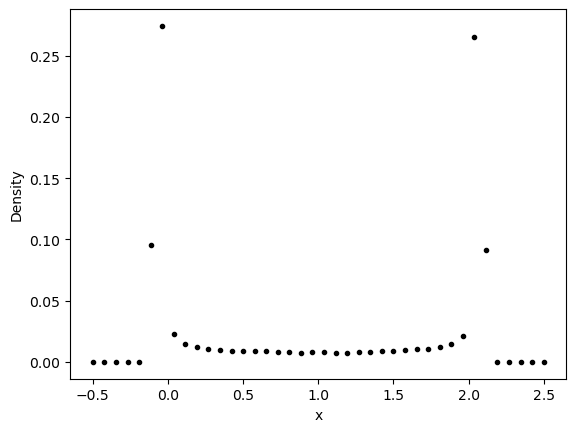

In [466]:
plt.plot(x_pt_array, arr_distr, '.', color = 'black')
plt.xlabel('x')
plt.ylabel('Density')
plt.savefig('density_chiral')

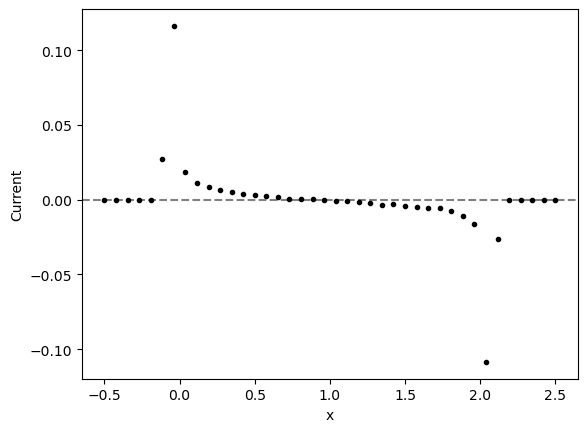

In [1406]:
plt.axhline(0, linestyle = '--', color = 'grey')
plt.plot(x_pt_array, current_distr, '.', color = 'black')
plt.xlabel('x')
plt.ylabel('Current')
plt.savefig('Current_distr')

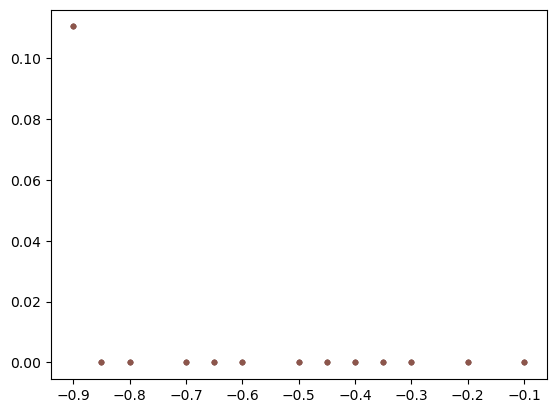

In [483]:
Dr_array = np.array([0.08, 0.09, 0.1, 0.2, 0.3, 0.4])
omega_array = np.array([-0.1, -0.2, -0.3, -0.35, -0.40, -0.45, -0.50, -0.60, -0.65, -0.70, -0.80, -0.85, -0.9])
current_grid = np.zeros((len(Dr_array), len(omega_array)))
for k in range(len(Dr_array)):
    for i in range(len(omega_array)):
        x, y, t = particle_trajectory(15, omega_array[i], Dr_array[k] , 2.0, 0.01, 30*50000, 1.0, 0.0, 0.8)
        L_min = -0.5
        L_max = 2.5
        N_bins = 40
        arr_distr = np.zeros(N_bins)
        vel_y_distr = np.zeros(N_bins)

        len_bin = (L_max - L_min)/N_bins

        x_pt_array = np.linspace(L_min, L_max, N_bins)

        speed_y_array = np.array([])

        for j in range(len(x) - 1):
            num = int((x[j] - L_min)//len_bin)
            arr_distr[num] += 1
            v_y = np.sin(t[j])
            vel_y_distr[num] += v_y

        vel_y_distr = vel_y_distr/(arr_distr + 10e-6)
        arr_distr /= len(x)

        current_distr = vel_y_distr*arr_distr

        current_grid[k][i] = 0.5*max(np.abs(current_distr - max(current_distr)))


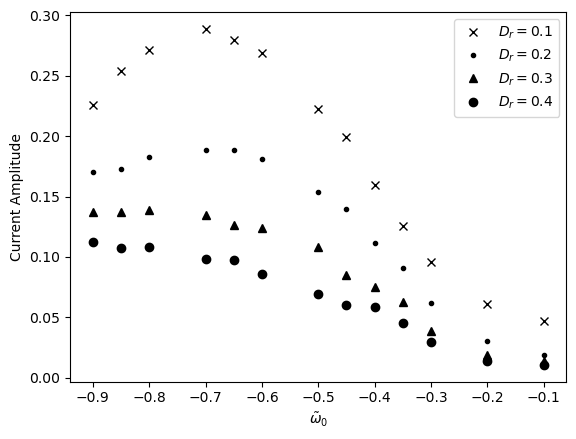

In [509]:
plt.plot(omega_array, current_grid[2], 'x', color = 'black', label = r'$D_r = 0.1$')
plt.plot(omega_array, current_grid[3], '.', color = 'black', label = r'$D_r = 0.2$')
plt.plot(omega_array, current_grid[4], '^', color = 'black', label = r'$D_r = 0.3$')
plt.plot(omega_array, current_grid[5], 'o', color = 'black', label = r'$D_r = 0.4$')
plt.xlabel(r'$\tilde{\omega}_0$')
plt.ylabel('Current Amplitude')
plt.legend()

#plt.savefig('chiral_current_amps')

In [1402]:
#Dr_array = np.array([0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.6, 0.9])
#Dr_array = np.array([0.06, 0.07, 0.08, 0.09, 0.10])
#Dr_array = np.array([0.4, 0.5, 0.6, 0.7, 0.8])
Dr_array = np.array([0.18, 0.22, 0.26])
omega_array = np.array([-0.1, -0.2, -0.3, -0.35, -0.40, -0.45, -0.50, -0.60, -0.65, -0.70, -0.80, -0.85, -0.9])

In [ ]:
time_array = np.zeros([len(omega_array), len(Dr_array)]) 

In [1339]:
for i in range(len(omega_array)):
    for j in range(len(Dr_array)):
        x, y, t = particle_trajectory(20, omega_array[i], Dr_array[j], 2.0, 0.01, 20*50000, 0.5, 0.0, 3.17)
        indices_array = np.array([])

        for k in range(len(x)):
            if ((x[k] < 0 and np.sin(t[k]) > 0) or (x[k] > 2.0 and np.sin(t[k]) < 0)):
                indices_array = np.append(indices_array, k)

        indices_array = np.abs(indices_array - np.roll(indices_array, 1))
        tau_array = np.array([])

        for l in range(len(indices_array)):
            if indices_array[l] > 1.5:
                tau_array = np.append(tau_array, l)

        tau_array = tau_array - np.roll(tau_array, 1)

        tau_array = np.delete(tau_array, 0)

        tau = np.sum(tau_array)/len(tau_array)
        tau = (tau/(200000))*0.01

        time_array[i][j] = tau
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12


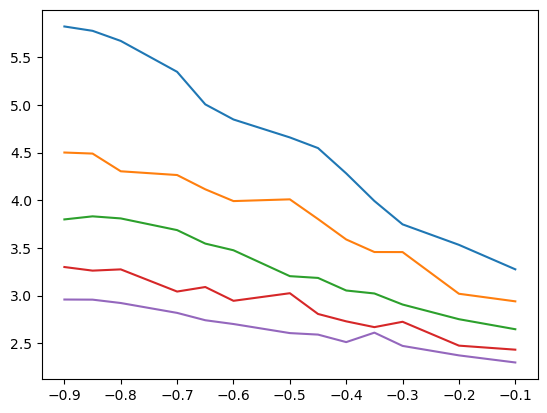

In [1298]:
for i in range(0, 5):
    plt.plot(omega_array, 10e6*(200000/(20*50000))*time_array[:,i], )

#plt.plot(omara, (1+np.exp(omara + 1))/(omara - 0.2))

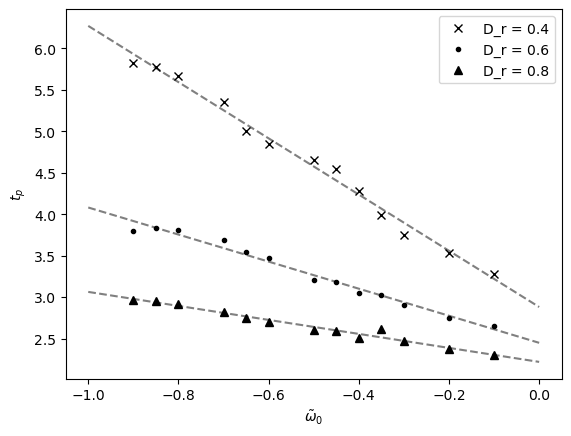

In [1315]:
plt.plot(omara, (200000/(20*50000))*(-16.95*omara + 14.40), linestyle = '--', color = 'grey')
plt.plot(omara, (200000/(20*50000))*(-8.16*omara + 12.24), linestyle = '--', color = 'grey')
plt.plot(omara, (200000/(20*50000))*(-4.22*omara + 11.09), linestyle = '--', color = 'grey')
plt.plot(omega_array, (200000/(20*50000))*10e6*time_array[:,0], 'x', color = 'black', label = r'D_r = 0.4')
plt.plot(omega_array, (200000/(20*50000))*10e6*time_array[:,2], '.', color = 'black', label = r'D_r = 0.6')
plt.plot(omega_array, (200000/(20*50000))*10e6*time_array[:,4], '^', color = 'black', label = r'D_r = 0.8')
plt.xlabel(r'$\tilde{\omega}_0$')
plt.ylabel(r'$t_p$')
plt.legend()

#plt.savefig('high_noise_fit')

-16.95237620851781 14.403320396997435


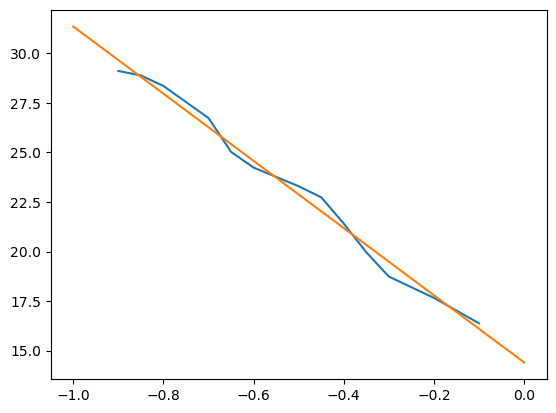

In [1299]:
plt.plot(omega_array, 10e6*time_array[:,0])

m, c = np.polyfit(omega_array, 10e6*time_array[:,0], 1)
print(m, c)

tr0 = m*omara + c
plt.plot(omara, tr0)

-10.084273537158376 13.931673911517324


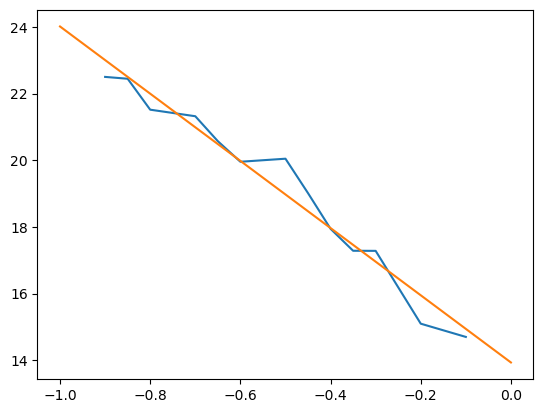

In [1300]:
#tiar2 = 180*skewnorm.pdf(-omara, -1, 0.50, 0.22)

plt.plot(omega_array, 10e6*time_array[:,1])
#plt.plot(-omara, tiar2)

m, c = np.polyfit(omega_array, 10e6*time_array[:,1], 1)


#tr2 = 5e6*np.exp(-14.5)*np.exp((np.exp(1.5*omara*omara + 1.23*omara + 0.34))/(0.09**(-1.85*omara*omara - 2.08*omara + 0.022)))
#plt.plot(omara, tr2)

tr1 = m*omara + c
#tr2 = 180*skewnorm.pdf(-omara, -1, 0.50, 0.22)
plt.plot(omara, tr1)

print(m, c)


-8.163056893484917 12.236802187725926


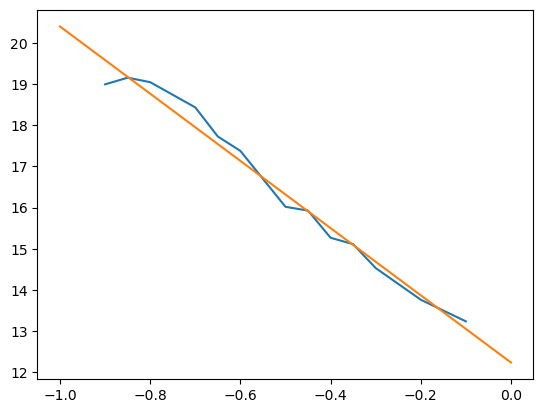

In [1301]:
plt.plot(omega_array, 10e6*time_array[:,2])

m, c = np.polyfit(omega_array, 10e6*time_array[:,2], 1)
print(m, c)

tr2 = m*omara + c
plt.plot(omara, tr2)

-5.6624437910358285 11.56820619885593


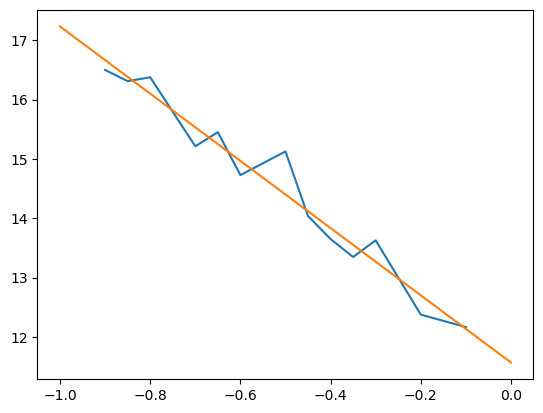

In [1302]:
plt.plot(omega_array, 10e6*time_array[:,3])

m, c = np.polyfit(omega_array, 10e6*time_array[:,3], 1)
print(m, c)

tr3 = m*omara + c
plt.plot(omara, tr3)

-4.22310220628594 11.085230186047806


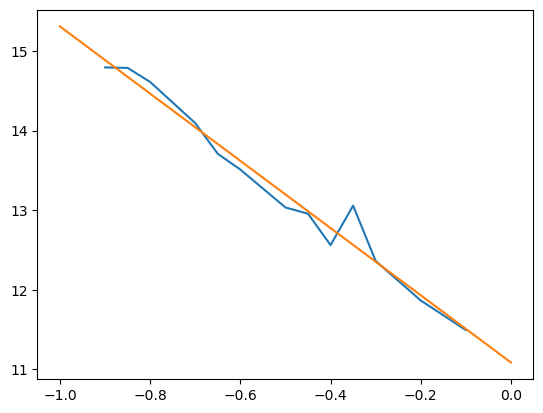

In [1303]:
plt.plot(omega_array, 10e6*time_array[:,4])

m, c = np.polyfit(omega_array, 10e6*time_array[:,4], 1)
print(m, c)

tr4 = m*omara + c
plt.plot(omara, tr4)

In [1325]:
Dr_ara2 = np.linspace(0.35, 0.9, 1000)

-9.929097302282681
8.551045941895316


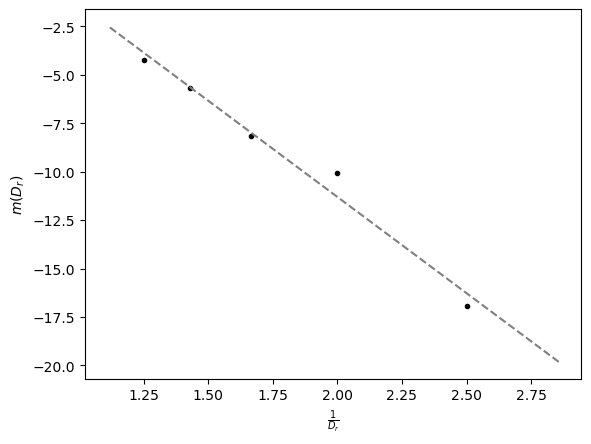

In [1331]:
m, c = np.polyfit(1/Dr_array, [-16.95, -10.08, -8.16, -5.66, -4.22], 1)
plt.plot(1/Dr_array, [-16.95, -10.08, -8.16, -5.66, -4.22], '.', color = 'black')
plt.plot(1/Dr_ara2, m*(1/Dr_ara2) + c, linestyle = '--', color = 'grey')
plt.xlabel(r'$\frac{1}{D_r}$')
plt.ylabel(r'$m(D_r)$')

print(m)
print(c)

#plt.savefig('slope_fit')

-11.560000000000004
19.638


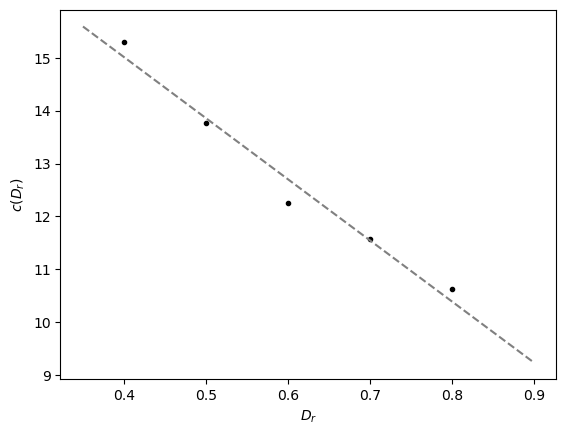

In [1335]:
m, c = np.polyfit(Dr_array, [15.30, 13.77, 12.25, 11.57, 10.62], 1)
plt.plot(Dr_array, [15.30, 13.77, 12.25, 11.57, 10.62], '.', color = 'black')
plt.plot(Dr_ara2, m*(Dr_ara2) + c, linestyle = '--', color = 'grey')
plt.xlabel(r'$D_r$')
plt.ylabel(r'$c(D_r)$')
print(m)
print(c)

#plt.savefig('const_fit')

In [1219]:
data1 = np.array([10.2, 10.04, 9.05, 10.30, 10.03, 9.14])
print(np.mean(data1))
print(sem(data1))

9.793333333333335
0.2249691336852926


In [1220]:
data2 = np.array([8.68, 8.44, 6.76, 9.04, 8.80, 7.21])
print(np.mean(data2))
print(sem(data2))

8.155
0.3827597157486665


In [1234]:
data3 = np.array([-9.95, -9.63, -10.51, -8.82, -8.85])
print(np.mean(data3))
print(sem(data3))

-9.552
0.3248753607154595


In [1235]:
data4 = np.array([18.43, 18.23, 18.78, 17.82, 17.98, 19.64])
print(np.mean(data4))
print(sem(data4))

18.48
0.26995061276710114


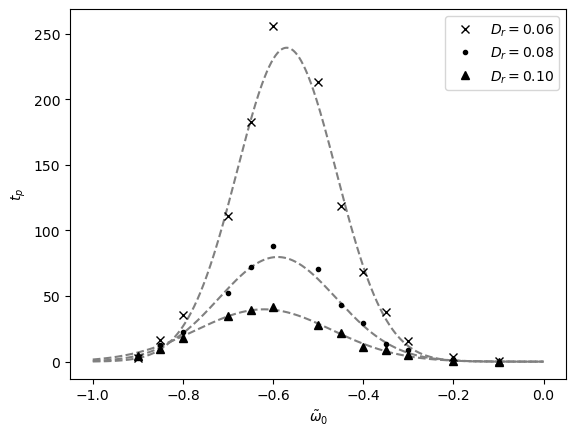

In [1273]:
plt.plot(omara, (200000/(20*50000))*330*norm.pdf(omara, -0.57, 0.11), linestyle = '--', color = 'grey')
plt.plot(omara, (200000/(20*50000))*130*norm.pdf(omara, -0.59, 0.13), linestyle = '--', color = 'grey')
plt.plot(omara, (200000/(20*50000))*75*norm.pdf(omara, -0.62, 0.15), linestyle = '--', color = 'grey')
plt.plot(omega_array, (10e6*time_array[:,0] + 155*omega_array - 17.9)*200000/(20*50000), 'x', color = 'black', label = r'$D_r = 0.06$')
plt.plot(omega_array, (10e6*time_array[:,2] + 114*omega_array - 17.7)*200000/(20*50000), '.', color = 'black', label = r'$D_r = 0.08$')
plt.plot(omega_array, (10e6*time_array[:,4] + 89.7*omega_array - 17.5)*200000/(20*50000), '^', color = 'black', label = r'$D_r = 0.10$')
plt.xlabel(r'$\tilde{\omega}_0$')
plt.ylabel(r'$t_p$')
plt.legend()

#plt.savefig('low_noise_fit')

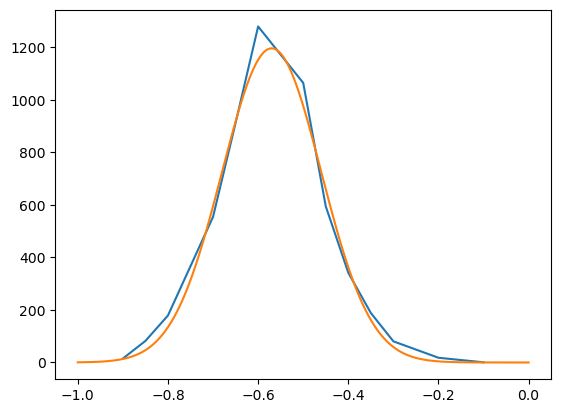

In [1238]:
#tr3 = 150*skewnorm.pdf(-omara, -1, 0.50, 0.26)

plt.plot(omega_array, 10e6*time_array[:,0] + 155*omega_array - 17.9)
#tr3 = 5.5e6*np.exp(-14.5)*np.exp((np.exp(1.5*omara*omara + 1.23*omara + 0.34))/(0.1**(-1.85*omara*omara - 2.08*omara + 0.022)))
#tr3 = 470*((-omara)**2.0)*norm.pdf(omara, -0.5, 0.20)
#plt.plot(-omara, tr3)

plt.plot(omara, 330*norm.pdf(omara, -0.57, 0.11))

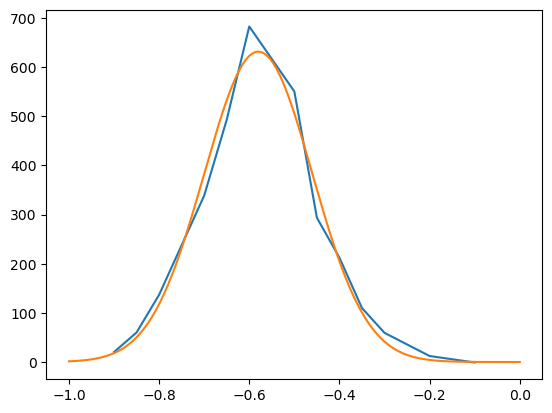

In [1239]:
plt.plot(omega_array, 10e6*time_array[:,1] + 132*omega_array - 17.8)
plt.plot(omara, 190*norm.pdf(omara, -0.58, 0.12))

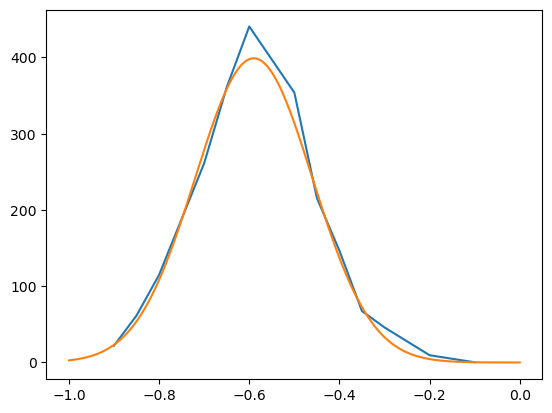

In [1240]:
plt.plot(omega_array, 10e6*time_array[:,2] + 114*omega_array - 17.7)
plt.plot(omara, 130*norm.pdf(omara, -0.59, 0.13))

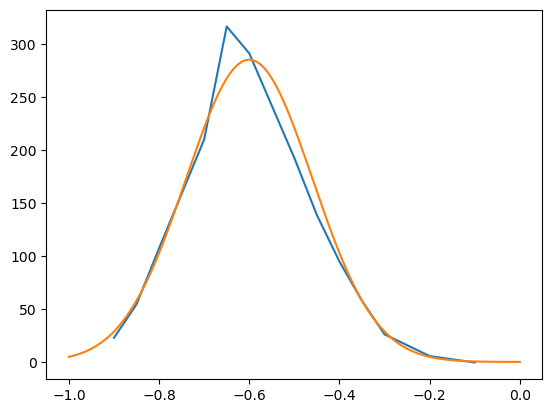

In [1241]:
plt.plot(omega_array, 10e6*time_array[:,3] + 101*omega_array - 17.6)
plt.plot(omara, 100*norm.pdf(omara, -0.60, 0.14))

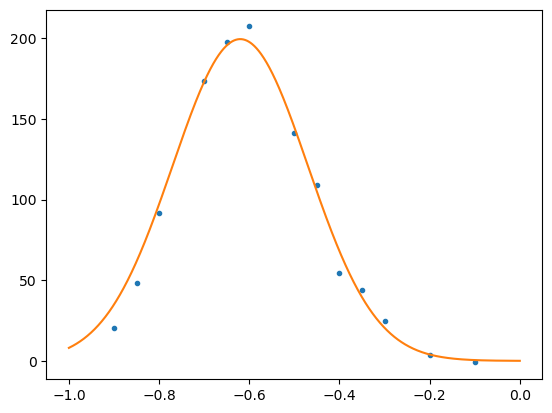

In [1265]:
plt.plot(omega_array, 10e6*time_array[:,4] + 89.7*omega_array - 17.5, '.')
plt.plot(omara, 75*norm.pdf(omara, -0.62, 0.15))

In [1275]:
Dr_ara = np.linspace(0.058, 0.102, 1000)

0.9999999999999989
0.05000000000000007


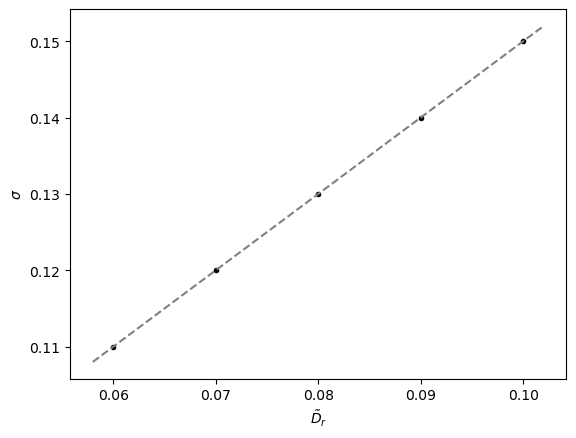

In [1292]:
m, c = np.polyfit(Dr_array, [0.11, 0.12, 0.13, 0.14, 0.15], 1)
plt.plot(Dr_array, [0.11, 0.12, 0.13, 0.14, 0.15], '.', color = 'black')
plt.plot(Dr_ara, m*Dr_ara + c, linestyle = '--', color = 'grey')
plt.xlabel(r'$\tilde{D}_r$')
plt.ylabel(r'$\sigma$')
print(m)
print(c)

#plt.savefig('sigma_fit')

0.003750043436666519
38.64945037868676


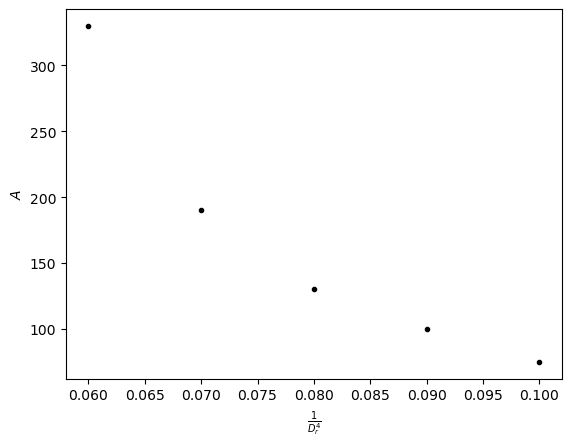

In [1400]:
m, c = np.polyfit(1/(Dr_array**4), [330, 190, 130, 100, 75], 1)
plt.plot(Dr_array, [330, 190, 130, 100, 75], '.', color = 'black')
#plt.plot(1/(Dr_ara**4), m*(1/(Dr_ara**4)) + c, linestyle = '--', color = 'grey')
plt.xlabel(r'$\frac{1}{D_r^4}$')
plt.ylabel(r'$A$')
print(m)
print(c)

#plt.savefig('amplitude_fit')

-1.1999999999999973
-0.49599999999999994


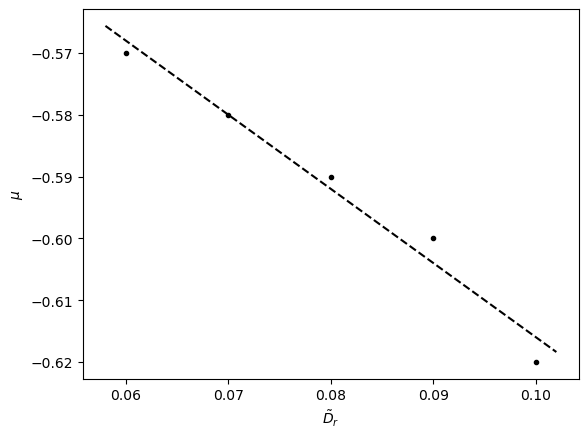

In [1294]:
m, c = np.polyfit(Dr_array, [-0.57, -0.58, -0.59, -0.60, -0.62], 1)
plt.plot(Dr_array, [-0.57, -0.58, -0.59, -0.60, -0.62], '.', color = 'black')
plt.plot(Dr_ara, m*Dr_ara + c, linestyle = '--', color = 'black')
plt.xlabel(r'$\tilde{D}_r$')
plt.ylabel(r'$\mu$')
print(m)
print(c)

#plt.savefig('mean_fit')